In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):##
    for filename in filenames:##
        print(os.path.join(dirname, filename))#

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/smartphone-decimeter-2023/sdc2023/sample_submission.csv
/kaggle/input/smartphone-decimeter-2023/sdc2023/metadata/constellation_type_mapping.csv
/kaggle/input/smartphone-decimeter-2023/sdc2023/metadata/accumulated_delta_range_state_bit_map.json
/kaggle/input/smartphone-decimeter-2023/sdc2023/metadata/raw_state_bit_map.json
/kaggle/input/smartphone-decimeter-2023/sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/device_gnss.csv
/kaggle/input/smartphone-decimeter-2023/sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/device_imu.csv
/kaggle/input/smartphone-decimeter-2023/sdc2023/test/2021-09-14-20-32-us-ca-mtv-k/pixel4/supplemental/gnss_log.txt
/kaggle/input/smartphone-decimeter-2023/sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/device_gnss.csv
/kaggle/input/smartphone-decimeter-2023/sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/device_imu.csv
/kaggle/input/smartphone-decimeter-2023/sdc2023/test/2021-08-17-20-37-us-ca-mtv-g/pixel5/supplemental/gnss_log.txt
/kaggle/input/

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None
import json

In [2]:
df = pd.read_csv('/kaggle/input/smartphone-decimeter-2023/sdc2023/sample_submission.csv')
df.head() 

,tripId,UnixTimeMillis,LatitudeDegrees,LongitudeDegrees
0,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715055442,34.640195,-120.589642
1,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715056442,34.640195,-120.589642
2,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715057442,34.640195,-120.589642
3,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715058442,34.640195,-120.589642
4,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715059442,34.640195,-120.589642


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71936 entries, 0 to 71935
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tripId            71936 non-null  object 
 1   UnixTimeMillis    71936 non-null  int64  
 2   LatitudeDegrees   71936 non-null  float64
 3   LongitudeDegrees  71936 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.2+ MB


In [5]:
df.dtypes

tripId               object
UnixTimeMillis        int64
LatitudeDegrees     float64
LongitudeDegrees    float64
dtype: object

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UnixTimeMillis,71936.0,1.656086e+12,1.950384e+10,1.607715e+12,1.645657e+12,1.650921e+12,1.682630e+12,1.686856e+12
LatitudeDegrees,71936.0,3.464019e+01,0.000000e+00,3.464019e+01,3.464019e+01,3.464019e+01,3.464019e+01,3.464019e+01
LongitudeDegrees,71936.0,-1.205896e+02,5.684381e-14,-1.205896e+02,-1.205896e+02,-1.205896e+02,-1.205896e+02,-1.205896e+02


In [7]:
df.columns

Index(['tripId', 'UnixTimeMillis', 'LatitudeDegrees', 'LongitudeDegrees'], dtype='object')

In [8]:
df.shape

(71936, 4)

<Axes: >

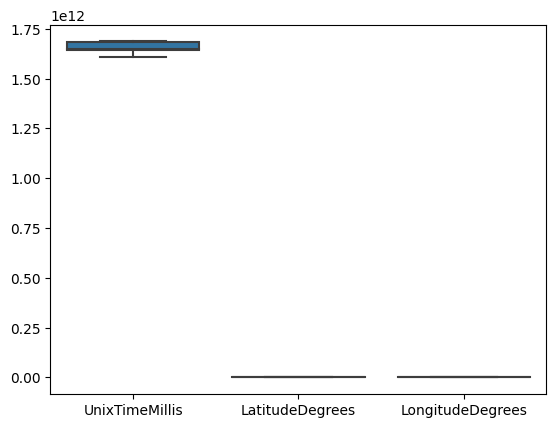

In [9]:
sns.boxplot(df)

<Axes: >

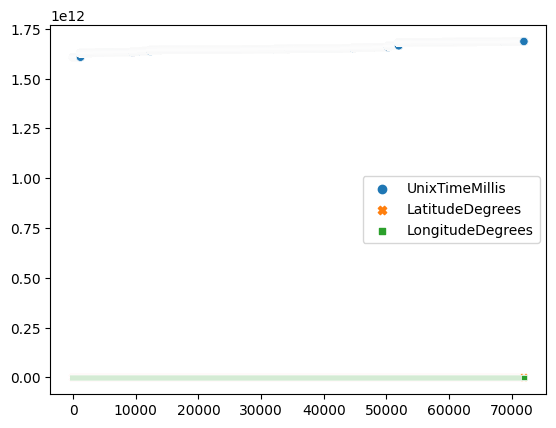

In [10]:
sns.scatterplot(df)

<Axes: >

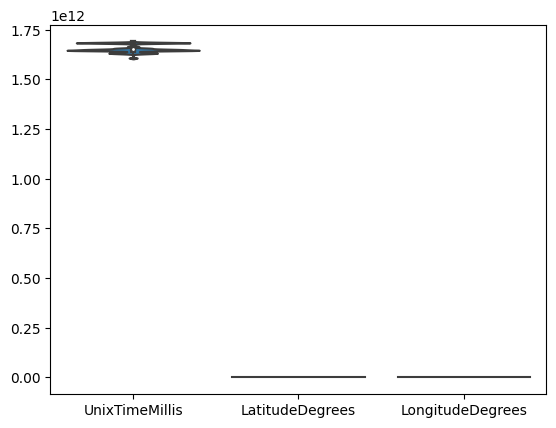

In [11]:
sns.violinplot(df)

<Axes: >

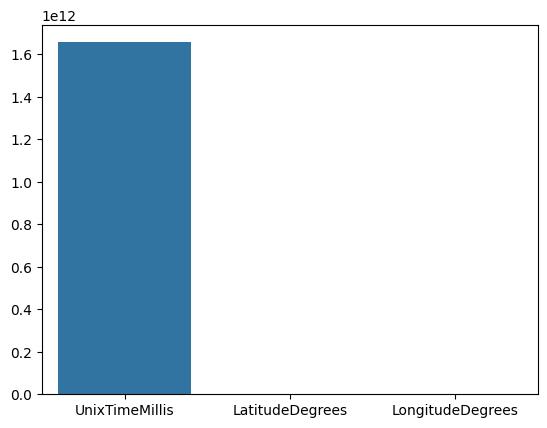

In [12]:
sns.barplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


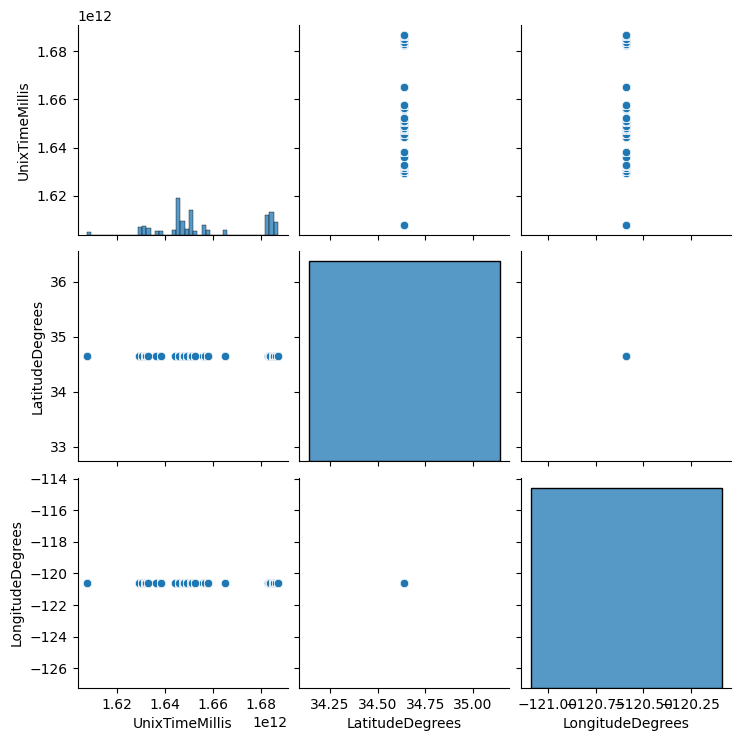

In [13]:
sns.pairplot(df)

/tmp/ipykernel_32/469203770.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df)


<Axes: ylabel='Density'>

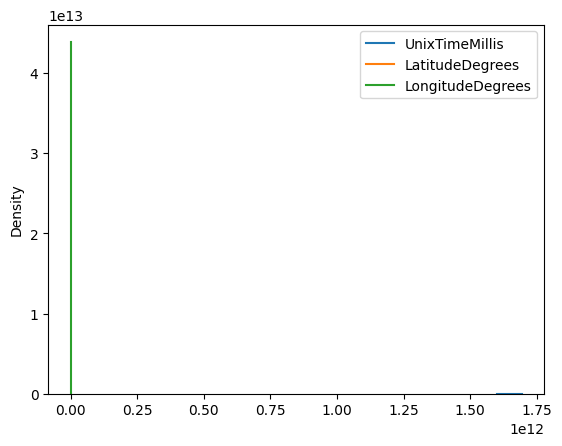

In [14]:
sns.kdeplot(df)

In [15]:
df.skew

<bound method NDFrame._add_numeric_operations.<locals>.skew of                                          tripId  UnixTimeMillis  \
0         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715055442   
1         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715056442   
2         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715057442   
3         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715058442   
4         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715059442   
...                                         ...             ...   
71931  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856468000   
71932  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856469000   
71933  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856470000   
71934  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856471000   
71935  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856472000   

       LatitudeDegrees  LongitudeDegrees  
0            34.640195       -120.589642  
1            34.640195       -120.589642  
2  

In [16]:
df.kurt

<bound method NDFrame._add_numeric_operations.<locals>.kurt of                                          tripId  UnixTimeMillis  \
0         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715055442   
1         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715056442   
2         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715057442   
3         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715058442   
4         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715059442   
...                                         ...             ...   
71931  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856468000   
71932  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856469000   
71933  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856470000   
71934  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856471000   
71935  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856472000   

       LatitudeDegrees  LongitudeDegrees  
0            34.640195       -120.589642  
1            34.640195       -120.589642  
2  

In [12]:
cat_cols = df.select_dtypes(include='object')

In [13]:
for i in cat_cols:
    print(i)
    print(df[i].value_counts())
    print(''*50)

tripId
tripId
2022-02-24-15-10-us-ca-lax-p/pixel5            4514
2022-02-24-22-14-us-ca-lax-i/pixel5            3581
2022-02-23-22-35-us-ca-lax-m/pixel5            2805
2021-09-28-21-56-us-ca-mtv-a/mi8               2479
2022-02-23-17-46-us-ca-lax-n/pixel5            2406
2023-05-09-23-10-us-ca-sjc-r/sm-a505u          2384
2022-04-04-16-31-us-ca-lax-x/pixel5            2170
2023-05-02-20-33-us-ca-mtv-xe1/pixel7pro       2144
2022-03-22-18-44-us-ca-mtv-pe1/pixel5          2111
2023-05-02-19-24-us-ca-sjc-we1/pixel7pro       2110
2023-05-23-21-06-us-ca-mtv-de1/pixel5          1974
2022-04-25-21-04-us-ca-ebf-x/mi8               1897
2022-06-22-20-12-us-ca-lax-hh/samsunga325g     1861
2022-06-28-20-56-us-ca-sjc-r/samsunga32        1829
2021-09-20-19-03-us-ca-mtv-l/pixel4            1796
2022-07-12-18-37-us-ca-mtv-b/sm-a325f          1782
2023-05-25-21-50-us-ca-sjc-ke2/sm-s908b        1728
2022-10-06-20-46-us-ca-sjc-r/sm-a205u          1699
2021-08-17-20-37-us-ca-mtv-g/pixel5            167

In [14]:
num_cols = df.select_dtypes(include='number')

In [15]:
for i in num_cols:
    print(i)
    print(df[i].value_counts())
    print(''*50)

UnixTimeMillis
UnixTimeMillis
1607715055442    1
1656451078000    1
1656451084000    1
1656451083000    1
1656451082000    1
                ..
1645741090445    1
1645741091445    1
1645741092445    1
1645741093445    1
1686856472000    1
Name: count, Length: 71936, dtype: int64

LatitudeDegrees
LatitudeDegrees
34.640195    71936
Name: count, dtype: int64

LongitudeDegrees
LongitudeDegrees
-120.589642    71936
Name: count, dtype: int64



In [31]:
df.kurt

<bound method NDFrame._add_numeric_operations.<locals>.kurt of                                          tripId  UnixTimeMillis  \
0         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715055442   
1         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715056442   
2         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715057442   
3         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715058442   
4         2020-12-11-19-30-us-ca-mtv-e/pixel4xl   1607715059442   
...                                         ...             ...   
71931  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856468000   
71932  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856469000   
71933  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856470000   
71934  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856471000   
71935  2023-06-15-18-49-us-ca-sjc-ce1/pixel7pro   1686856472000   

       LatitudeDegrees  LongitudeDegrees  
0            34.640195       -120.589642  
1            34.640195       -120.589642  
2  

In [3]:
df.columns

Index(['tripId', 'UnixTimeMillis', 'LatitudeDegrees', 'LongitudeDegrees'], dtype='object')

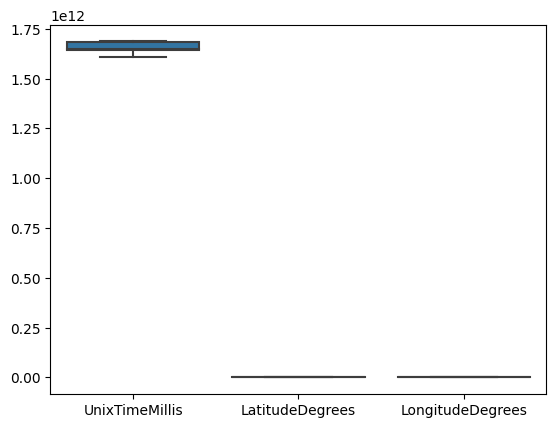

In [19]:
x = 1
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    sns.boxplot(data=df)
    print('\n')
    plt.show()

/tmp/ipykernel_32/1835564512.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df)


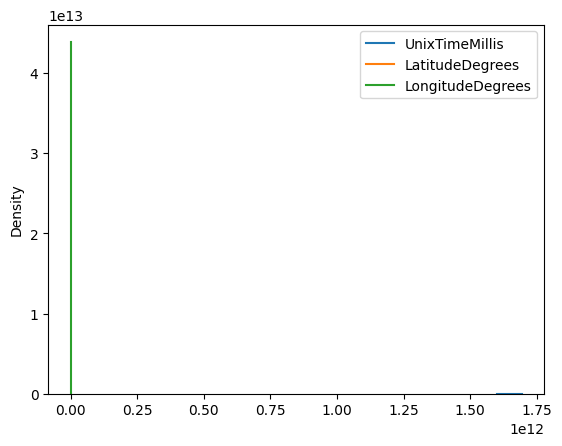

/tmp/ipykernel_32/1835564512.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df)


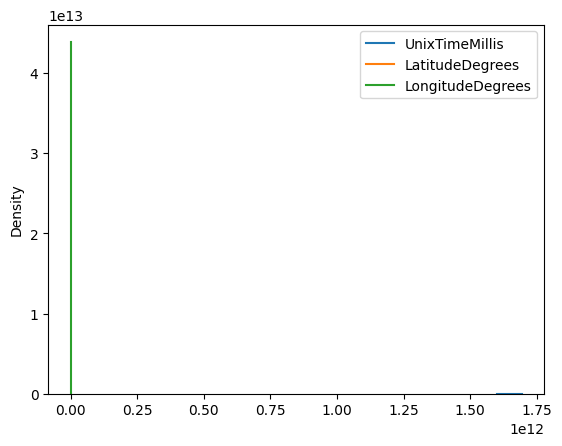

/tmp/ipykernel_32/1835564512.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df)


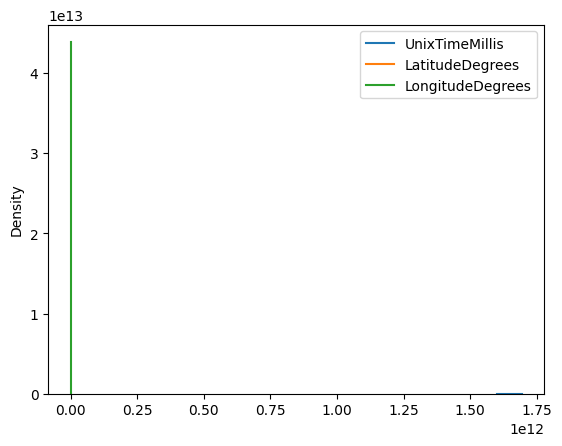

In [20]:
x = 1
num_cols = df.select_dtypes(include='number')
for i in num_cols:
    sns.kdeplot(data=df)
    print('\n')
    plt.show()

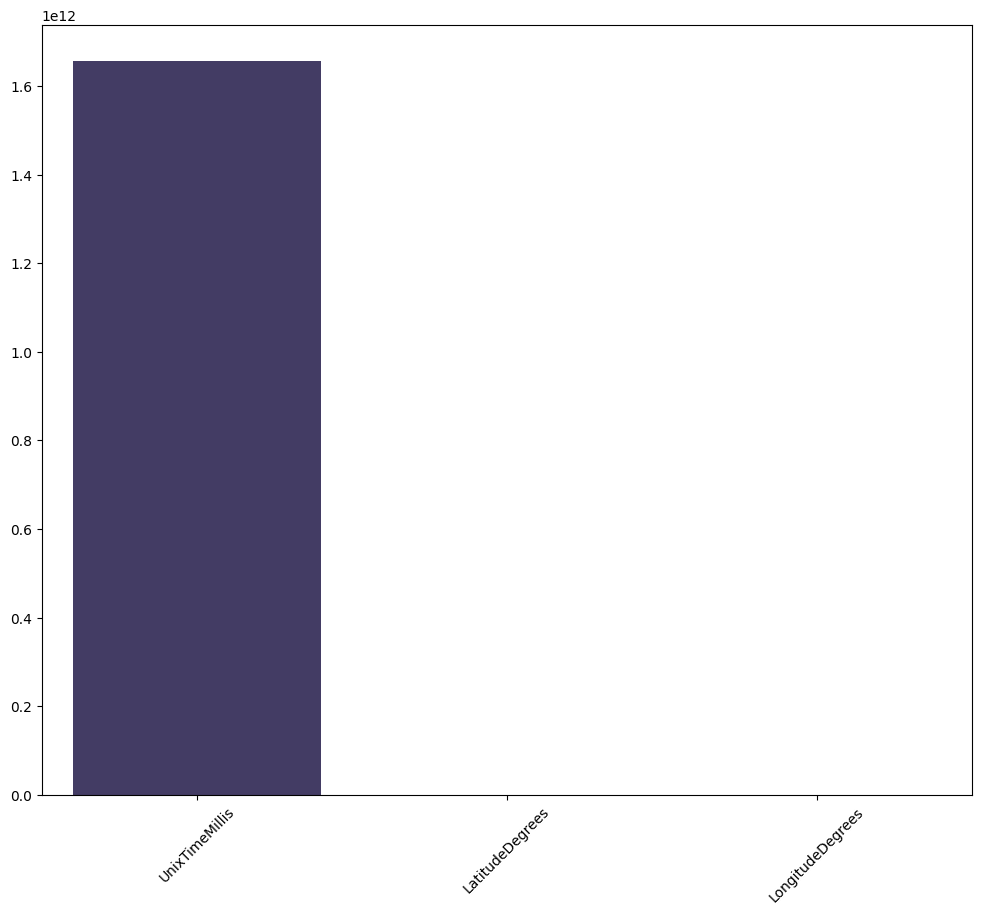

In [21]:
plt.figure(figsize=(12,10))
sns.barplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

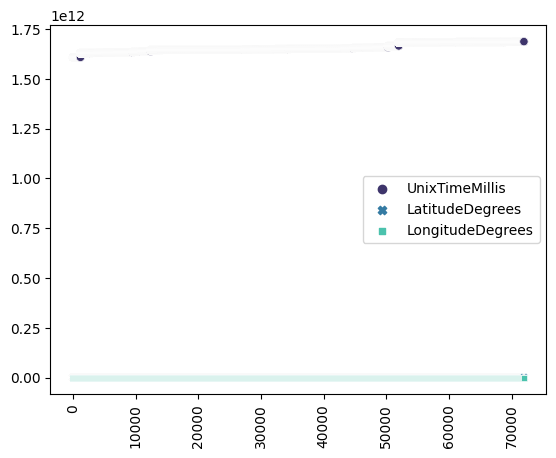

In [22]:
sns.scatterplot(data=df,palette='mako');
plt.xticks(rotation=90);
plt.show()

/tmp/ipykernel_32/1279175190.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df,palette='mako');


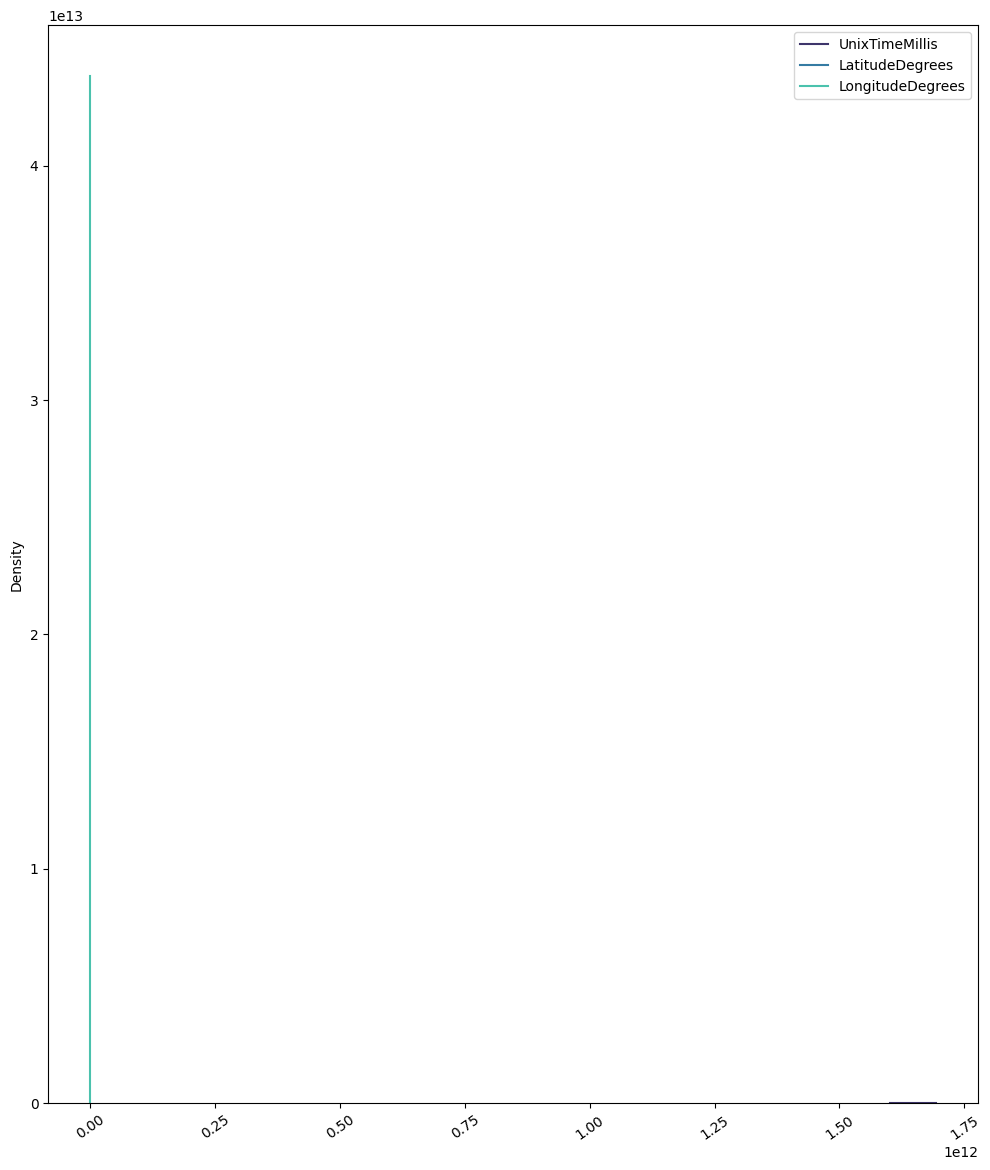

In [23]:
plt.figure(figsize=(12,14))
sns.kdeplot(data=df,palette='mako');
plt.xticks(rotation=35);
plt.show()

In [24]:
df.head()

,tripId,UnixTimeMillis,LatitudeDegrees,LongitudeDegrees
0,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715055442,34.640195,-120.589642
1,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715056442,34.640195,-120.589642
2,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715057442,34.640195,-120.589642
3,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715058442,34.640195,-120.589642
4,2020-12-11-19-30-us-ca-mtv-e/pixel4xl,1607715059442,34.640195,-120.589642


In [25]:
x = df[['UnixTimeMillis']]

In [26]:
y = df[['UnixTimeMillis']]

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
lr = LinearRegression